# Code for assignment2

## Exercise 1(a): HP-filtered business cycle components (US vs Portugal)
This section loads quarterly GDP, consumption, and investment data for both countries, takes logs, applies the HP filter with $\lambda=1600$, and plots the cyclical components.

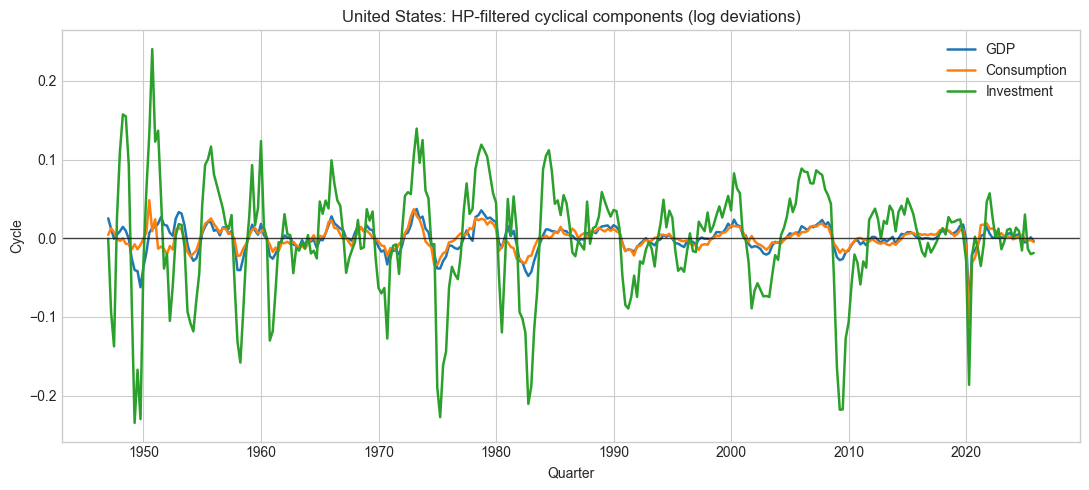

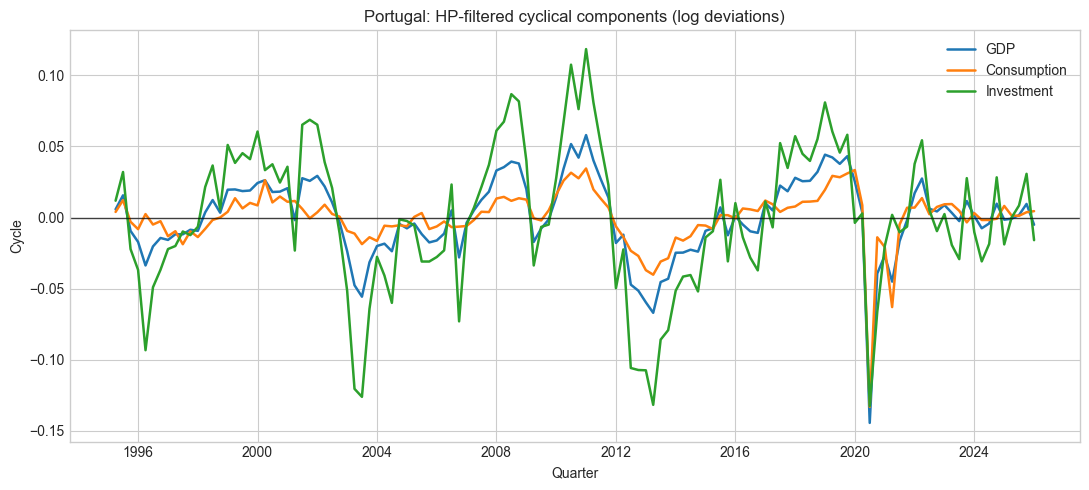

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.filters.hp_filter import hpfilter

plt.style.use("seaborn-v0_8-whitegrid")


def dedupe_index(series: pd.Series, keep: str = "last") -> pd.Series:
    if not series.index.is_unique:
        if keep == "mean":
            series = series.groupby(level=0).mean()
        else:
            series = series[~series.index.duplicated(keep=keep)]
    return series.sort_index()


def load_fred_series(filename: str, value_col: str) -> pd.Series:
    df = pd.read_csv(filename)
    dates = pd.to_datetime(df["observation_date"])
    values = pd.to_numeric(df[value_col], errors="coerce")
    series = pd.Series(np.log(values.values), index=dates, name=value_col).dropna()
    return dedupe_index(series, keep="last")


def load_eurostat_series(filename: str, label: str) -> pd.Series:
    df = pd.read_csv(filename)
    dates = pd.PeriodIndex(df["TIME_PERIOD"], freq="Q").to_timestamp(how="end")
    values = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
    series = pd.Series(np.log(values.values), index=dates, name=label).dropna()
    return dedupe_index(series, keep="mean")


# Data files are in the same folder as this notebook.
base_path = Path(".")

us_log = {
    "GDP": load_fred_series(base_path / "GDPC1.csv", "GDPC1"),
    "Consumption": load_fred_series(base_path / "PCECC96.csv", "PCECC96"),
    "Investment": load_fred_series(base_path / "GPDIC1.csv", "GPDIC1"),
}

pt_log = {
    "GDP": load_eurostat_series(base_path / "namq_10_gdp__custom_b1gq__20907889_linear.csv", "B1GQ"),
    "Consumption": load_eurostat_series(base_path / "namq_10_gdp__custom_p3_20908104_linear.csv", "P3"),
    "Investment": load_eurostat_series(base_path / "namq_10_gdp__custom_p5g_20908153_linear.csv", "P5G"),
}


def hp_cycle_dict(series_dict: dict[str, pd.Series], lamb: float = 1600) -> pd.DataFrame:
    cycles = {}
    for name, s in series_dict.items():
        s = dedupe_index(s, keep="mean")
        cycle, _trend = hpfilter(s, lamb=lamb)
        cycles[name] = cycle
    return pd.concat(cycles, axis=1).dropna(how="all")


us_cycle = hp_cycle_dict(us_log, lamb=1600)
pt_cycle = hp_cycle_dict(pt_log, lamb=1600)


def plot_country_cycles(cycle_df: pd.DataFrame, country_name: str) -> None:
    fig, ax = plt.subplots(figsize=(11, 5))
    for col in cycle_df.columns:
        ax.plot(cycle_df.index, cycle_df[col], linewidth=1.8, label=col)
    ax.axhline(0, color="black", linewidth=1, alpha=0.7)
    ax.set_title(f"{country_name}: HP-filtered cyclical components (log deviations)")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Cycle")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_country_cycles(us_cycle, "United States")
plot_country_cycles(pt_cycle, "Portugal")

## Exercise 1(b): Relative volatility of consumption and investment
We compute standard deviations of the HP-filtered cyclical components and compare them to output volatility using

- $\sigma_c / \sigma_y$
- $\sigma_i / \sigma_y$

where $y$ is GDP, $c$ is consumption, and $i$ is investment.

In [4]:
def volatility_summary(cycle_df: pd.DataFrame, country: str) -> pd.Series:
    stds = cycle_df[["GDP", "Consumption", "Investment"]].std()
    return pd.Series(
        {
            "country": country,
            "sigma_y": stds["GDP"],
            "sigma_c": stds["Consumption"],
            "sigma_i": stds["Investment"],
            "sigma_c_over_sigma_y": stds["Consumption"] / stds["GDP"],
            "sigma_i_over_sigma_y": stds["Investment"] / stds["GDP"],
        }
    )


vol_table = pd.DataFrame(
    [
        volatility_summary(us_cycle, "United States"),
        volatility_summary(pt_cycle, "Portugal"),
    ]
).set_index("country")

# Display main results with readable formatting.
display(vol_table.round(4))

for country, row in vol_table.iterrows():
    c_ratio = row["sigma_c_over_sigma_y"]
    i_ratio = row["sigma_i_over_sigma_y"]
    c_text = "< 1 (consumption less volatile than output)" if c_ratio < 1 else ">= 1 (consumption not less volatile than output)"
    i_text = ">> 1 (investment much more volatile than output)" if i_ratio > 1.5 else "> 1 (investment more volatile than output, but not by a lot)"
    print(f"{country}: sigma_c/sigma_y = {c_ratio:.3f} -> {c_text}")
    print(f"{country}: sigma_i/sigma_y = {i_ratio:.3f} -> {i_text}\n")

print("Discussion:")
print("Both countries show the standard business-cycle pattern: consumption is smoother than GDP, while investment is much more volatile.")
print("The broad qualitative pattern is similar across countries, though the exact magnitudes differ.")

,sigma_y,sigma_c,sigma_i,sigma_c_over_sigma_y,sigma_i_over_sigma_y
country,,,,,
United States,0.0162,0.0137,0.0708,0.8427,4.3592
Portugal,0.0281,0.0191,0.0510,0.6799,1.8134


United States: sigma_c/sigma_y = 0.843 -> < 1 (consumption less volatile than output)
United States: sigma_i/sigma_y = 4.359 -> >> 1 (investment much more volatile than output)

Portugal: sigma_c/sigma_y = 0.680 -> < 1 (consumption less volatile than output)
Portugal: sigma_i/sigma_y = 1.813 -> >> 1 (investment much more volatile than output)

Discussion:
Both countries show the standard business-cycle pattern: consumption is smoother than GDP, while investment is much more volatile.
The broad qualitative pattern is similar across countries, though the exact magnitudes differ.


## Exercise 1(c): Welfare cost comparison with CRRA utility
Assume $u(c)=\frac{c^{1-\gamma}-1}{1-\gamma}$ with $\gamma=1.99$ and consumption fluctuations
$\tilde c_t = 1+\varepsilon_t$, where $\varepsilon_t\sim U[-\varepsilon,\varepsilon]$.

Using $\sigma(\tilde c_t)=\frac{2\varepsilon}{\sqrt{12}}=\frac{\varepsilon}{\sqrt{3}}$, we map empirical $\sigma_c$ to model $\varepsilon$:

$$\varepsilon = \sqrt{3}\,\sigma_c.$$

Then

$$\mathbb{E}[(1+\varepsilon_t)^{1-\gamma}] = \frac{1}{2\varepsilon}\frac{1}{2-\gamma}\left[(1+\varepsilon)^{2-\gamma}-(1-\varepsilon)^{2-\gamma}\right].$$

We compute the compensating $\lambda$ that makes the agent indifferent between business-cycle risk in the two countries:

$$\mathbb{E}[u((1+\lambda)\tilde c^{US})]=\mathbb{E}[u(\tilde c^{PT})].$$

With CRRA this implies

$$1+\lambda = \left(\frac{\mathbb{E}[(\tilde c^{US})^{1-\gamma}]}{\mathbb{E}[(\tilde c^{PT})^{1-\gamma}] }\right)^{\frac{1}{\gamma-1}}.$$

In [5]:
gamma = 1.99

sigma_c_us = float(vol_table.loc["United States", "sigma_c"])
sigma_c_pt = float(vol_table.loc["Portugal", "sigma_c"])

# Match model volatility: if c_t = 1 + eps_t and eps_t ~ U[-eps, eps], then sigma(c_t) = eps/sqrt(3).
eps_us = np.sqrt(3) * sigma_c_us
eps_pt = np.sqrt(3) * sigma_c_pt


def E_power_uniform_eps(eps: float, gamma: float) -> float:
    """Compute E[(1+eps_t)^(1-gamma)] for eps_t ~ U[-eps, eps]."""
    num = (1 + eps) ** (2 - gamma) - (1 - eps) ** (2 - gamma)
    den = 2 * eps * (2 - gamma)
    return num / den


E_us = E_power_uniform_eps(eps_us, gamma)
E_pt = E_power_uniform_eps(eps_pt, gamma)

# Lambda that makes US-risk utility equal PT-risk utility:
# E[u((1+lambda)c_US)] = E[u(c_PT)]
lambda_us_to_pt = (E_us / E_pt) ** (1 / (gamma - 1)) - 1

# Also compute the reverse comparison for completeness.
lambda_pt_to_us = (E_pt / E_us) ** (1 / (gamma - 1)) - 1

result_c = pd.DataFrame(
    {
        "sigma_c": [sigma_c_us, sigma_c_pt],
        "epsilon_matched": [eps_us, eps_pt],
        "E[(1+eps_t)^(1-gamma)]": [E_us, E_pt],
    },
    index=["United States", "Portugal"],
)

display(result_c.round(6))

print(f"gamma = {gamma}")
print(f"lambda (US -> PT indifference) = {lambda_us_to_pt:.6f} ({100*lambda_us_to_pt:.4f}%)")
print(f"lambda (PT -> US indifference) = {lambda_pt_to_us:.6f} ({100*lambda_pt_to_us:.4f}%)")

if lambda_us_to_pt > 0:
    print("Interpretation: To be indifferent between the two countries' business-cycle risk,"
          " US consumption would need to be scaled up by lambda relative to Portugal.")
else:
    print("Interpretation: A negative lambda would mean US risk is lower in this calibration.")

,sigma_c,epsilon_matched,E[(1+eps_t)^(1-gamma)]
United States,0.013681,0.023697,1.000184
Portugal,0.019122,0.033121,1.000360


gamma = 1.99
lambda (US -> PT indifference) = -0.000178 (-0.0178%)
lambda (PT -> US indifference) = 0.000178 (0.0178%)
Interpretation: A negative lambda would mean US risk is lower in this calibration.


## Exercise 1(d): Recompute welfare cost for $\gamma=4$
We keep the same empirically matched $\sigma_c$ (and therefore the same $\varepsilon$) and only change risk aversion from $\gamma=1.99$ to $\gamma=4$.

In [6]:
gamma_d = 4.0

# Reuse eps_us and eps_pt computed in part (c) from empirical sigma_c.
E_us_d = E_power_uniform_eps(eps_us, gamma_d)
E_pt_d = E_power_uniform_eps(eps_pt, gamma_d)

lambda_us_to_pt_d = (E_us_d / E_pt_d) ** (1 / (gamma_d - 1)) - 1
lambda_pt_to_us_d = (E_pt_d / E_us_d) ** (1 / (gamma_d - 1)) - 1

print(f"gamma = {gamma_d:.2f}")
print(f"lambda (US -> PT indifference) = {lambda_us_to_pt_d:.6f} ({100*lambda_us_to_pt_d:.4f}%)")
print(f"lambda (PT -> US indifference) = {lambda_pt_to_us_d:.6f} ({100*lambda_pt_to_us_d:.4f}%)")

# Compare to part (c), where gamma = 1.99.
print(f"For gamma = 1.99, lambda (PT -> US) was {100*lambda_pt_to_us:.4f}%")
print(f"For gamma = 4.00, lambda (PT -> US) is {100*lambda_pt_to_us_d:.4f}%")

if abs(lambda_pt_to_us_d) > abs(lambda_pt_to_us):
    print("Lambda is bigger in absolute value: higher risk aversion raises the welfare cost of consumption volatility.")
else:
    print("Lambda is smaller in absolute value for this sample/calibration.")

gamma = 4.00
lambda (US -> PT indifference) = -0.000357 (-0.0357%)
lambda (PT -> US indifference) = 0.000357 (0.0357%)
For gamma = 1.99, lambda (PT -> US) was 0.0178%
For gamma = 4.00, lambda (PT -> US) is 0.0357%
Lambda is bigger in absolute value: higher risk aversion raises the welfare cost of consumption volatility.
